✅ Libraries imported successfully
Math students    : 395
Portuguese students: 649
Total combined   : 1044
Columns          : 34

Cleaned dataset shape: (991, 9)
Missing values: 0
=== Grade Distribution ===
count    991.000000
mean      11.948537
std        2.912248
min        1.000000
25%       10.000000
50%       12.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

=== Pass / Fail Count ===
Pass (G3 >= 10): 814
Fail (G3  <  10): 177

=== Correlations with G3 ===
G3           1.000000
G2           0.947509
G1           0.875994
studytime    0.189321
subject      0.109494
famsup      -0.028158
schoolsup   -0.161128
absences    -0.218030
failures    -0.349391
Name: G3, dtype: float64


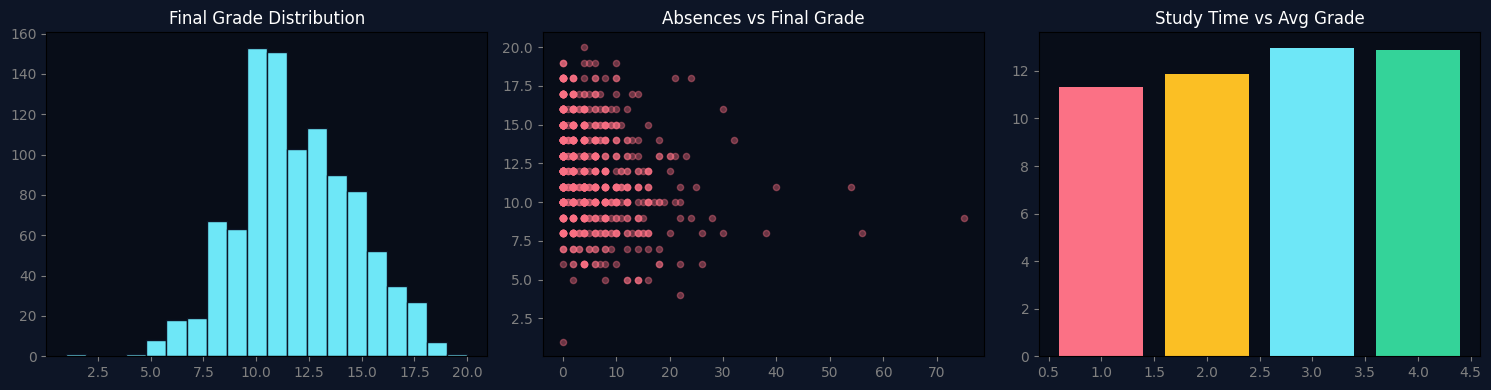

✅ EDA charts saved as eda_charts.png
Training samples : 792
Testing  samples : 199
Features used    : ['studytime', 'failures', 'absences', 'G1', 'G2', 'schoolsup', 'famsup', 'subject']
Linear Regression          R² = 0.908   MAE = 0.711
Decision Tree              R² = 0.903   MAE = 0.713
Random Forest              R² = 0.884   MAE = 0.779

✅ Best model: Linear Regression
Final Model  R² : 0.884
Final Model MAE : 0.779
✅ Model saved → student_grade_model.pkl

=== Raw Feature Importance (from Random Forest) ===
  Feature  Importance
       G2    0.903566
       G1    0.025242
 absences    0.024273
studytime    0.013777
   famsup    0.011247
  subject    0.008356
 failures    0.007992
schoolsup    0.005547


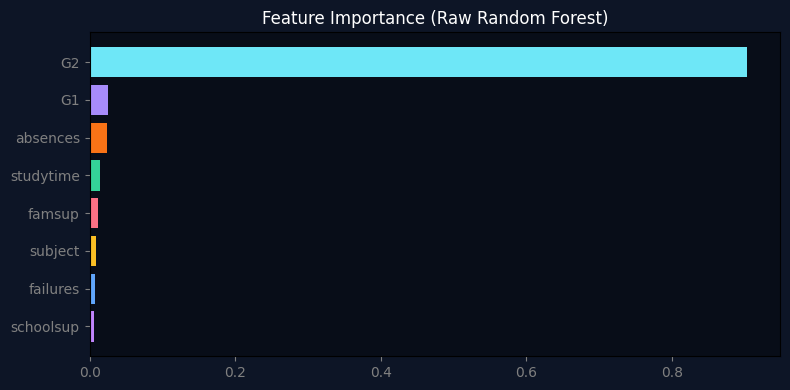

✅ Feature importance chart saved → feature_importance.png


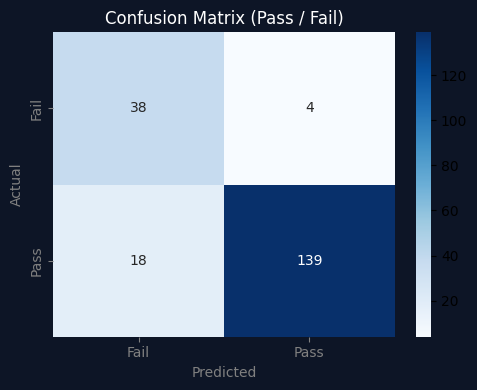


=== Classification Report ===
              precision    recall  f1-score   support

        Fail       0.68      0.90      0.78        42
        Pass       0.97      0.89      0.93       157

    accuracy                           0.89       199
   macro avg       0.83      0.90      0.85       199
weighted avg       0.91      0.89      0.89       199

✅ Confusion matrix saved → confusion_matrix.png

=== Files in project folder ===
  ✅ Found  →  student_grade_model.pkl
  ✅ Found  →  eda_charts.png
  ✅ Found  →  feature_importance.png
  ✅ Found  →  confusion_matrix.png

🎉 model_training complete! You can now run:  py -m streamlit run app.py


In [2]:


# ── CELL 1 : Import Libraries ────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model    import LinearRegression
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import RandomForestRegressor
from sklearn.metrics         import r2_score, mean_absolute_error

print("✅ Libraries imported successfully")


# ── CELL 2 : Load & Combine Dataset ─────────────────────────
mat = pd.read_csv("student-mat.csv", sep=";")
por = pd.read_csv("student-por.csv", sep=";")

mat["subject"] = "Math"
por["subject"] = "Portuguese"

data = pd.concat([mat, por], ignore_index=True)

print("Math students    :", len(mat))
print("Portuguese students:", len(por))
print("Total combined   :", len(data))
print("Columns          :", data.shape[1])


# ── CELL 3 : Select & Clean Features ────────────────────────
# Keep only the features we use in the prediction model
data = data[[
    "studytime",
    "failures",
    "absences",
    "G1",
    "G2",
    "schoolsup",
    "famsup",
    "subject",
    "G3"          # ← Target variable (final grade)
]]

# Convert Yes/No columns to 1/0
data["schoolsup"] = data["schoolsup"].map({"yes": 1, "no": 0})
data["famsup"]    = data["famsup"].map({"yes": 1, "no": 0})

# Convert subject text to number
data["subject"] = data["subject"].map({"Math": 0, "Portuguese": 1})

# Drop rows where G3 = 0  (likely dropouts / absent — ambiguous data)
data = data[data["G3"] > 0]

print("\nCleaned dataset shape:", data.shape)
print("Missing values:", data.isnull().sum().sum())
data.head()


# ── CELL 4 : Explore the Data (EDA) ─────────────────────────
print("=== Grade Distribution ===")
print(data["G3"].describe())

print("\n=== Pass / Fail Count ===")
print("Pass (G3 >= 10):", (data["G3"] >= 10).sum())
print("Fail (G3  <  10):", (data["G3"] <  10).sum())

print("\n=== Correlations with G3 ===")
print(data.corr(numeric_only=True)["G3"].sort_values(ascending=False))


# ── CELL 5 : Visualise Key Relationships ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.patch.set_facecolor("#0d1526")

# Grade distribution
axes[0].hist(data["G3"], bins=20, color="#6ee7f7", edgecolor="#0d1526")
axes[0].set_title("Final Grade Distribution", color="white")
axes[0].set_facecolor("#080d18")
axes[0].tick_params(colors="gray")

# Absences vs G3
axes[1].scatter(data["absences"], data["G3"],
                alpha=0.4, color="#fb7185", s=20)
axes[1].set_title("Absences vs Final Grade", color="white")
axes[1].set_facecolor("#080d18")
axes[1].tick_params(colors="gray")

# Study time vs G3
study_avg = data.groupby("studytime")["G3"].mean()
axes[2].bar(study_avg.index, study_avg.values,
            color=["#fb7185","#fbbf24","#6ee7f7","#34d399"])
axes[2].set_title("Study Time vs Avg Grade", color="white")
axes[2].set_facecolor("#080d18")
axes[2].tick_params(colors="gray")

plt.tight_layout()
plt.savefig("eda_charts.png", dpi=120, bbox_inches="tight",
            facecolor="#0d1526")
plt.show()
print("✅ EDA charts saved as eda_charts.png")


# ── CELL 6 : Train / Test Split ─────────────────────────────
X = data.drop("G3", axis=1)
y = data["G3"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples :", len(X_train))
print("Testing  samples :", len(X_test))
print("Features used    :", list(X.columns))


# ── CELL 7 : Compare 3 Models ───────────────────────────────
models = {
    "Linear Regression"   : LinearRegression(),
    "Decision Tree"       : DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest"       : RandomForestRegressor(n_estimators=200, random_state=42),
}

results = {}
for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    pred  = mdl.predict(X_test)
    r2    = round(r2_score(y_test, pred), 3)
    mae   = round(mean_absolute_error(y_test, pred), 3)
    results[name] = {"R2": r2, "MAE": mae}
    print(f"{name:25s}  R² = {r2}   MAE = {mae}")

best_model_name = max(results, key=lambda k: results[k]["R2"])
print(f"\n✅ Best model: {best_model_name}")


# ── CELL 8 : Train Final Model & Save ───────────────────────
final_model = RandomForestRegressor(n_estimators=200, random_state=42)
final_model.fit(X_train, y_train)

final_pred = final_model.predict(X_test)
print("Final Model  R² :", round(r2_score(y_test, final_pred), 3))
print("Final Model MAE :", round(mean_absolute_error(y_test, final_pred), 3))

# Save the trained model
with open("student_grade_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

print("✅ Model saved → student_grade_model.pkl")


# ── CELL 9 : Feature Importance Chart ───────────────────────
importances   = final_model.feature_importances_
feature_names = X.columns
fi_df = pd.DataFrame({
    "Feature"   : feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print("\n=== Raw Feature Importance (from Random Forest) ===")
print(fi_df.to_string(index=False))

fig2, ax = plt.subplots(figsize=(8, 4))
fig2.patch.set_facecolor("#0d1526")
ax.set_facecolor("#080d18")
colors = ["#6ee7f7","#a78bfa","#f97316","#34d399","#fb7185","#fbbf24","#60a5fa","#c084fc"]
ax.barh(fi_df["Feature"], fi_df["Importance"], color=colors[:len(fi_df)])
ax.set_title("Feature Importance (Raw Random Forest)", color="white")
ax.tick_params(colors="gray")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120, bbox_inches="tight",
            facecolor="#0d1526")
plt.show()
print("✅ Feature importance chart saved → feature_importance.png")


# ── CELL 10 : Confusion Matrix (Pass / Fail) ────────────────
from sklearn.metrics import confusion_matrix, classification_report

# Convert to Pass/Fail for classification view
y_test_cls  = (y_test >= 10).astype(int)
y_pred_cls  = (final_pred >= 10).astype(int)

cm = confusion_matrix(y_test_cls, y_pred_cls)

fig3, ax3 = plt.subplots(figsize=(5, 4))
fig3.patch.set_facecolor("#0d1526")
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fail","Pass"],
            yticklabels=["Fail","Pass"], ax=ax3)
ax3.set_title("Confusion Matrix (Pass / Fail)", color="white")
ax3.set_xlabel("Predicted", color="gray")
ax3.set_ylabel("Actual", color="gray")
ax3.tick_params(colors="gray")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120, bbox_inches="tight",
            facecolor="#0d1526")
plt.show()

print("\n=== Classification Report ===")
print(classification_report(y_test_cls, y_pred_cls,
                             target_names=["Fail","Pass"]))
print("✅ Confusion matrix saved → confusion_matrix.png")


# ── CELL 11 : Verify Everything is Saved ────────────────────
files = ["student_grade_model.pkl",
         "eda_charts.png",
         "feature_importance.png",
         "confusion_matrix.png"]

print("\n=== Files in project folder ===")
for f in files:
    status = "✅ Found" if os.path.exists(f) else "❌ Missing"
    print(f"  {status}  →  {f}")

print("\n🎉 model_training complete! You can now run:  py -m streamlit run app.py")